In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_rel
import pandas as pd
# Index,SSIM,RMSE,PSNR

In [9]:
def calculate_mean(df):
    columns_to_calculate = ['SSIM', 'RMSE', 'PSNR']
    columns_to_calculate = [col for col in columns_to_calculate if col in df.columns]
    return df[columns_to_calculate].mean()

def calculate_std(df):
    columns_to_calculate = ['SSIM', 'RMSE', 'PSNR']
    columns_to_calculate = [col for col in columns_to_calculate if col in df.columns]
    return df[columns_to_calculate].std()

In [10]:
def plot_distributions(df, model: str):

    columns_to_plot = ['SSIM', 'RMSE', 'PSNR']
    num_columns = len(columns_to_plot)

    fig, axes = plt.subplots(1, num_columns, figsize=(15, 5), sharey=True)

    for i, col in enumerate(columns_to_plot):
        sns.histplot(df[col], kde=True, bins=30, ax=axes[i])
        axes[i].set_title(f"Distribution of {col} for {model}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [11]:
def table_full(metrics_dict):
    for model, filepath in metrics_dict.items():
        df = pd.read_csv(filepath)
        mean_values = calculate_mean(df)
        std_values = calculate_std(df)

        print(f"Statistics for {model}:")
        for col in mean_values.index:
            print(f"{col}: Mean {mean_values[col]:.4f} Std {std_values[col]:.4f}")
        print("\n")

        plot_distributions(df, model=model)

In [12]:
def table(metrics_dict):
    for model, filepath in metrics_dict.items():
        df = pd.read_csv(filepath)
        mean_values = calculate_mean(df)
        std_values = calculate_std(df)

        print(f"Statistics for {model}:")
        for col in mean_values.index:
            mean_str = f"{mean_values[col]:.4f}"
            std_str = f"{std_values[col]:.4f}"
            # .replace('.', ',')
            print(f"{col}: Mean {mean_str} Std {std_str}")
        print("\n")
def table_latex(metrics_dict):
    all_metrics = {'SSIM': {}, 'RMSE': {}, 'PSNR': {}}

    for model, filepath in metrics_dict.items():
        df = pd.read_csv(filepath)
        mean_values = calculate_mean(df)
        std_values = calculate_std(df)

        for metric in all_metrics.keys():
            mean_str = f"{mean_values[metric]:.3f}"
            std_str = f"{std_values[metric]:.3f}"
            all_metrics[metric][model] = f"{mean_str} $\\pm$ {std_str}"

    for metric, values in all_metrics.items():
        print(f"\\textbf{{{metric}}}: & " + " & ".join(values.values())+' \\\ \\hline')


In [13]:
def create_metric_tables(metrics_dict, output_filepath):
    data = {
        "Model": [],
        "Context": [],
        "SSIM_Mean": [],
        "SSIM_Std": [],
        "RMSE_Mean": [],
        "RMSE_Std": [],
        "PSNR_Mean": [],
        "PSNR_Std": [],
    }
    for model, filepath in metrics_dict.items():
        parts = model.split()
        model_name = parts[0] + parts[1]
        context = int(parts[-1])
        df = pd.read_csv(filepath)
        mean_values = df.mean()
        std_values = df.std()
        data["Model"].append(model_name)
        data["Context"].append(context)
        data["SSIM_Mean"].append(mean_values["SSIM"])
        data["SSIM_Std"].append(std_values["SSIM"])
        data["RMSE_Mean"].append(mean_values["RMSE"])
        data["RMSE_Std"].append(std_values["RMSE"])
        data["PSNR_Mean"].append(mean_values["PSNR"])
        data["PSNR_Std"].append(std_values["PSNR"])

    df_summary = pd.DataFrame(data)

    with pd.ExcelWriter(output_filepath) as writer:
        for metric in ["SSIM_Mean", "RMSE_Mean", "PSNR_Mean", "SSIM_Std", "RMSE_Std", "PSNR_Std"]:
            pivot_table = df_summary.pivot(index="Model", columns="Context", values=metric)
            pivot_table.to_excel(writer, sheet_name=metric)

    print(f"Metrics tables saved to {output_filepath}")

In [14]:
Semi_alpha = {
    'Baseline' : 'test_results/OADAT/Semi/Semi_baseline.csv',
    'Unet' : 'test_results/OADAT/Semi/Unet_Generalized_alpha_Semi.csv',
    'PA OmniNet' : 'test_results/OADAT/Semi/PAOmniNet_Generalized_alpha_Semi.csv',
}

Semi_mse = {
    'Baseline' : 'test_results/OADAT/Semi/Semi_baseline.csv',
    'Unet' : 'test_results/OADAT/Semi/Unet_Generalized_mse_Semi.csv',
    'PA OmniNet' : 'test_results/OADAT/Semi/PAOmniNet_Generalized_mse_Semi.csv',
}

Semi_ssim = {
    'Baseline' : 'test_results/OADAT/Semi/Semi_baseline.csv',
    'Unet' : 'test_results/OADAT/Semi/Unet_Generalized_ssim_Semi.csv',
    'PA OmniNet' : 'test_results/OADAT/Semi/PAOmniNet_Generalized_ssim_Semi.csv',
}

Multi_alpha = {
    'Baseline' : 'test_results/OADAT/Multi/Multi_baseline.csv',
    'Unet Generalized' : 'test_results/OADAT/Multi/Unet_Generalized_alpha_Multi.csv',
    'Unet Specific' : 'test_results/OADAT/Multi/Unet_Specific_alpha_Multi.csv',
    'PA OmniNet Generalized' : 'test_results/OADAT/Multi/PAOmniNet_Generalized_alpha_Multi.csv',
    'PA OmniNet Specific' : 'test_results/OADAT/Multi/PAOmniNet_Specific_alpha_Multi.csv'
}

Multi_mse = {
    'Baseline' : 'test_results/OADAT/Multi/Multi_baseline.csv',
    'Unet Generalized' : 'test_results/OADAT/Multi/Unet_Generalized_mse_Multi.csv',
    'Unet Specific' : 'test_results/OADAT/Multi/Unet_Specific_mse_Multi.csv',
    'PA OmniNet Generalized' : 'test_results/OADAT/Multi/PAOmniNet_Generalized_mse_Multi.csv',
    'PA OmniNet Specific' : 'test_results/OADAT/Multi/PAOmniNet_Specific_mse_Multi.csv'
}

Multi_ssim= {
    'Baseline' : 'test_results/OADAT/Multi/Multi_baseline.csv',
    'Unet Generalized' : 'test_results/OADAT/Multi/Unet_Generalized_ssim_Multi.csv',
    'Unet Specific' : 'test_results/OADAT/Multi/Unet_Specific_ssim_Multi.csv',
    'PA OmniNet Generalized' : 'test_results/OADAT/Multi/PAOmniNet_Generalized_ssim_Multi.csv',
    'PA OmniNet Specific' : 'test_results/OADAT/Multi/PAOmniNet_Specific_ssim_Multi.csv'
}

MSFD_alpha = {
    'Baseline' : 'test_results/OADAT/MSFD/MSFD_baseline.csv',
    'Unet Generalized' : 'test_results/OADAT/MSFD/Unet_Generalized_alpha_MSFD.csv',
    'Unet Specific' : 'test_results/OADAT/MSFD/Unet_Specific_alpha_MSFD.csv',
    'PA OmniNet Generalized' : 'test_results/OADAT/MSFD/PAOmniNet_Generalized_alpha_MSFD.csv',
    'PA OmniNet Specific' : 'test_results/OADAT/MSFD/PAOmniNet_Specific_alpha_MSFD.csv'
}

MSFD_mse = {
    'Baseline' : 'test_results/OADAT/MSFD/MSFD_baseline.csv',
    'Unet Generalized' : 'test_results/OADAT/MSFD/Unet_Generalized_mse_MSFD.csv',
    'Unet Specific' : 'test_results/OADAT/MSFD/Unet_Specific_mse_MSFD.csv',
    'PA OmniNet Generalized' : 'test_results/OADAT/MSFD/PAOmniNet_Generalized_mse_MSFD.csv',
    'PA OmniNet Specific' : 'test_results/OADAT/MSFD/PAOmniNet_Specific_mse_MSFD.csv'
}

MSFD_ssim= {
    'Baseline' : 'test_results/OADAT/MSFD/MSFD_baseline.csv',
    'Unet Generalized' : 'test_results/OADAT/MSFD/Unet_Generalized_ssim_MSFD.csv',
    'Unet Specific' : 'test_results/OADAT/MSFD/Unet_Specific_ssim_MSFD.csv',
    'PA OmniNet Generalized' : 'test_results/OADAT/MSFD/PAOmniNet_Generalized_ssim_MSFD.csv',
    'PA OmniNet Specific' : 'test_results/OADAT/MSFD/PAOmniNet_Specific_ssim_MSFD.csv'
}

SCD_alpha = {
    'Baseline' : 'test_results/OADAT/SCD/SCD_baseline.csv',
    'Unet Generalized' : 'test_results/OADAT/SCD/Unet_Generalized_alpha_SCD.csv',
    'Unet Specific' : 'test_results/OADAT/SCD/Unet_Specific_alpha_SCD.csv',
    'PA OmniNet Generalized' : 'test_results/OADAT/SCD/PAOmniNet_Generalized_alpha_SCD.csv',
    'PA OmniNet Specific' : 'test_results/OADAT/SCD/PAOmniNet_Specific_alpha_SCD.csv'
}

SCD_mse = {
    'Baseline' : 'test_results/OADAT/SCD/SCD_baseline.csv',
    'Unet Generalized' : 'test_results/OADAT/SCD/Unet_Generalized_mse_SCD.csv',
    'Unet Specific' : 'test_results/OADAT/SCD/Unet_Specific_mse_SCD.csv',
    'PA OmniNet Generalized' : 'test_results/OADAT/SCD/PAOmniNet_Generalized_mse_SCD.csv',
    'PA OmniNet Specific' : 'test_results/OADAT/SCD/PAOmniNet_Specific_mse_SCD.csv'
}

SCD_ssim= {
    'Baseline' : 'test_results/OADAT/SCD/SCD_baseline.csv',
    'Unet Generalized' : 'test_results/OADAT/SCD/Unet_Generalized_ssim_SCD.csv',
    'Unet Specific' : 'test_results/OADAT/SCD/Unet_Specific_ssim_SCD.csv',
    'PA OmniNet Generalized' : 'test_results/OADAT/SCD/PAOmniNet_Generalized_ssim_SCD.csv',
    'PA OmniNet Specific' : 'test_results/OADAT/SCD/PAOmniNet_Specific_ssim_SCD.csv'
}

In [37]:
table(Multi_mse)

Statistics for Baseline:
SSIM: Mean 0.4003 Std 0.0639
RMSE: Mean 0.0804 Std 0.0293
PSNR: Mean 22.4400 Std 3.0677


Statistics for Unet Generalized:
SSIM: Mean 0.6376 Std 0.1619
RMSE: Mean 0.0601 Std 0.0299
PSNR: Mean 25.4123 Std 4.1371


Statistics for Unet Specific:
SSIM: Mean 0.6410 Std 0.1608
RMSE: Mean 0.0609 Std 0.0303
PSNR: Mean 25.3309 Std 4.2752


Statistics for PA OmniNet Generalized:
SSIM: Mean 0.6471 Std 0.1779
RMSE: Mean 0.0533 Std 0.0303
PSNR: Mean 26.6600 Std 4.5090


Statistics for PA OmniNet Specific:
SSIM: Mean 0.6604 Std 0.1727
RMSE: Mean 0.0489 Std 0.0283
PSNR: Mean 27.4735 Std 4.6121




In [15]:
print( ' \multicolumn{6}{c}{\\textbf{MSFD MSE}} \\\ \hline')
table_latex(MSFD_mse)
print( ' \multicolumn{6}{c}{\\textbf{MSFD Alpha}} \\\ \hline')
table_latex(MSFD_alpha)
print( ' \multicolumn{6}{c}{\\textbf{MSFD SSIM}} \\\ \hline')
table_latex(MSFD_ssim)

 \multicolumn{6}{c}{\textbf{MSFD MSE}} \\ \hline
\textbf{SSIM}: & 0.452 $\pm$ 0.078 & 0.713 $\pm$ 0.101 & 0.758 $\pm$ 0.089 & 0.740 $\pm$ 0.107 & 0.755 $\pm$ 0.103 \\ \hline
\textbf{RMSE}: & 0.079 $\pm$ 0.025 & 0.059 $\pm$ 0.028 & 0.050 $\pm$ 0.025 & 0.048 $\pm$ 0.024 & 0.042 $\pm$ 0.023 \\ \hline
\textbf{PSNR}: & 22.460 $\pm$ 2.606 & 25.395 $\pm$ 3.578 & 26.927 $\pm$ 3.672 & 27.277 $\pm$ 3.789 & 28.592 $\pm$ 4.225 \\ \hline
 \multicolumn{6}{c}{\textbf{MSFD Alpha}} \\ \hline
\textbf{SSIM}: & 0.452 $\pm$ 0.078 & 0.612 $\pm$ 0.215 & 0.452 $\pm$ 0.092 & 0.751 $\pm$ 0.101 & 0.782 $\pm$ 0.099 \\ \hline
\textbf{RMSE}: & 0.079 $\pm$ 0.025 & 0.141 $\pm$ 0.126 & 0.608 $\pm$ 0.069 & 0.046 $\pm$ 0.024 & 0.040 $\pm$ 0.022 \\ \hline
\textbf{PSNR}: & 22.460 $\pm$ 2.606 & 20.023 $\pm$ 7.121 & 4.378 $\pm$ 1.020 & 27.794 $\pm$ 4.121 & 28.989 $\pm$ 4.203 \\ \hline
 \multicolumn{6}{c}{\textbf{MSFD SSIM}} \\ \hline
\textbf{SSIM}: & 0.452 $\pm$ 0.078 & 0.571 $\pm$ 0.108 & 0.577 $\pm$ 0.109 & 0.752 $\pm$ 0.

In [16]:
Mouse16_alpha = {
    'Baseline' : 'test_results/mice/mouse16/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse16/Unet_Generalized_mouse16_alpha.csv',
    'Unet Specific' : 'test_results/mice/mouse16/Unet_Specific_mouse16_alpha.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse16/PAOmniNet_Generalized_mouse16_alpha.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse16/PAOmniNet_Specific_mouse16_alpha.csv'
}

Mouse16_mse = {
    'Baseline' : 'test_results/mice/mouse16/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse16/Unet_Generalized_mouse16_mse.csv',
    'Unet Specific' : 'test_results/mice/mouse16/Unet_Specific_mouse16_mse.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse16/PAOmniNet_Generalized_mouse16_mse.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse16/PAOmniNet_Specific_mouse16_mse.csv'
}

Mouse16_ssim= {
    'Baseline' : 'test_results/mice/mouse16/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse16/Unet_Generalized_mouse16_ssim.csv',
    'Unet Specific' : 'test_results/mice/mouse16/Unet_Specific_mouse16_ssim.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse16/PAOmniNet_Generalized_mouse16_ssim.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse16/PAOmniNet_Specific_mouse16_ssim.csv'
}

Mouse32_alpha = {
    'Baseline' : 'test_results/mice/mouse32/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse32/Unet_Generalized_mouse32_alpha.csv',
    'Unet Specific' : 'test_results/mice/mouse32/Unet_Specific_mouse32_alpha.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse32/PAOmniNet_Generalized_mouse32_alpha.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse32/PAOmniNet_Specific_mouse32_alpha.csv'
}

Mouse32_mse = {
    'Baseline' : 'test_results/mice/mouse32/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse32/Unet_Generalized_mouse32_mse.csv',
    'Unet Specific' : 'test_results/mice/mouse32/Unet_Specific_mouse32_mse.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse32/PAOmniNet_Generalized_mouse32_mse.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse32/PAOmniNet_Specific_mouse32_mse.csv'
}

Mouse32_ssim= {
    'Baseline' : 'test_results/mice/mouse32/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse32/Unet_Generalized_mouse32_ssim.csv',
    'Unet Specific' : 'test_results/mice/mouse32/Unet_Specific_mouse32_ssim.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse32/PAOmniNet_Generalized_mouse32_ssim.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse32/PAOmniNet_Specific_mouse32_ssim.csv'
}

Mouse64_alpha = {
    'Baseline' : 'test_results/mice/mouse64/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse64/Unet_Generalized_mouse64_alpha.csv',
    'Unet Specific' : 'test_results/mice/mouse64/Unet_Specific_mouse64_alpha.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse64/PAOmniNet_Generalized_mouse64_alpha.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse64/PAOmniNet_Specific_mouse64_alpha.csv'
}

Mouse64_mse = {
    'Baseline' : 'test_results/mice/mouse64/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse64/Unet_Generalized_mouse64_mse.csv',
    'Unet Specific' : 'test_results/mice/mouse64/Unet_Specific_mouse64_mse.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse64/PAOmniNet_Generalized_mouse64_mse.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse64/PAOmniNet_Specific_mouse64_mse.csv'
}

Mouse64_ssim= {
    'Baseline' : 'test_results/mice/mouse64/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse64/Unet_Generalized_mouse64_ssim.csv',
    'Unet Specific' : 'test_results/mice/mouse64/Unet_Specific_mouse64_ssim.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse64/PAOmniNet_Generalized_mouse64_ssim.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse64/PAOmniNet_Specific_mouse64_ssim.csv'
}
Mouse128_alpha = {
    'Baseline' : 'test_results/mice/mouse128/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse128/Unet_Generalized_mouse128_alpha.csv',
    'Unet Specific' : 'test_results/mice/mouse128/Unet_Specific_mouse128_alpha.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse128/PAOmniNet_Generalized_mouse128_alpha.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse128/PAOmniNet_Specific_mouse128_alpha.csv'
}

Mouse128_mse = {
    'Baseline' : 'test_results/mice/mouse128/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse128/Unet_Generalized_mouse128_mse.csv',
    'Unet Specific' : 'test_results/mice/mouse128/Unet_Specific_mouse128_mse.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse128/PAOmniNet_Generalized_mouse128_mse.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse128/PAOmniNet_Specific_mouse128_mse.csv'
}

Mouse128_ssim= {
    'Baseline' : 'test_results/mice/mouse128/baseline.csv',
    'Unet Generalized' : 'test_results/mice/mouse128/Unet_Generalized_mouse128_ssim.csv',
    'Unet Specific' : 'test_results/mice/mouse128/Unet_Specific_mouse128_ssim.csv',
    'PA OmniNet Generalized' : 'test_results/mice/mouse128/PAOmniNet_Generalized_mouse128_ssim.csv',
    'PA OmniNet Specific' : 'test_results/mice/mouse128/PAOmniNet_Specific_mouse128_ssim.csv'
}

Vphantom16_alpha = {
    'Baseline' : 'test_results/mice/vphantom16/baseline.csv',
    'Unet Generalized' : 'test_results/mice/vphantom16/Unet_Generalized_vphantom16_alpha.csv',
    'Unet Specific' : 'test_results/mice/vphantom16/Unet_Specific_vphantom16_alpha.csv',
    'PA OmniNet Generalized' : 'test_results/mice/vphantom16/PAOmniNet_Generalized_vphantom16_alpha.csv',
    'PA OmniNet Specific' : 'test_results/mice/vphantom16/PAOmniNet_Specific_vphantom16_alpha.csv'
}

Vphantom16_mse = {
    'Baseline' : 'test_results/mice/vphantom16/baseline.csv',
    'Unet Generalized' : 'test_results/mice/vphantom16/Unet_Generalized_vphantom16_mse.csv',
    'Unet Specific' : 'test_results/mice/vphantom16/Unet_Specific_vphantom16_mse.csv',
    'PA OmniNet Generalized' : 'test_results/mice/vphantom16/PAOmniNet_Generalized_vphantom16_mse.csv',
    'PA OmniNet Specific' : 'test_results/mice/vphantom16/PAOmniNet_Specific_vphantom16_mse.csv'
}

Vphantom16_ssim= {
    'Baseline' : 'test_results/mice/vphantom16/baseline.csv',
    'Unet Generalized' : 'test_results/mice/vphantom16/Unet_Generalized_vphantom16_ssim.csv',
    'Unet Specific' : 'test_results/mice/vphantom16/Unet_Specific_vphantom16_ssim.csv',
    'PA OmniNet Generalized' : 'test_results/mice/vphantom16/PAOmniNet_Generalized_vphantom16_ssim.csv',
    'PA OmniNet Specific' : 'test_results/mice/vphantom16/PAOmniNet_Specific_vphantom16_ssim.csv'
}

Vphantom32_alpha = {
    'Baseline' : 'test_results/mice/vphantom32/baseline.csv',
    'Unet Generalized' : 'test_results/mice/vphantom32/Unet_Generalized_vphantom32_alpha.csv',
    'Unet Specific' : 'test_results/mice/vphantom32/Unet_Specific_vphantom32_alpha.csv',
    'PA OmniNet Generalized' : 'test_results/mice/vphantom32/PAOmniNet_Generalized_vphantom32_alpha.csv',
    'PA OmniNet Specific' : 'test_results/mice/vphantom32/PAOmniNet_Specific_vphantom32_alpha.csv'
}

Vphantom32_mse = {
    'Baseline' : 'test_results/mice/vphantom32/baseline.csv',
    'Unet Generalized' : 'test_results/mice/vphantom32/Unet_Generalized_vphantom32_mse.csv',
    'Unet Specific' : 'test_results/mice/vphantom32/Unet_Specific_vphantom32_mse.csv',
    'PA OmniNet Generalized' : 'test_results/mice/vphantom32/PAOmniNet_Generalized_vphantom32_mse.csv',
    'PA OmniNet Specific' : 'test_results/mice/vphantom32/PAOmniNet_Specific_vphantom32_mse.csv'
}

Vphantom32_ssim= {
    'Baseline' : 'test_results/mice/vphantom32/baseline.csv',
    'Unet Generalized' : 'test_results/mice/vphantom32/Unet_Generalized_vphantom32_ssim.csv',
    'Unet Specific' : 'test_results/mice/vphantom32/Unet_Specific_vphantom32_ssim.csv',
    'PA OmniNet Generalized' : 'test_results/mice/vphantom32/PAOmniNet_Generalized_vphantom32_ssim.csv',
    'PA OmniNet Specific' : 'test_results/mice/vphantom32/PAOmniNet_Specific_vphantom32_ssim.csv'
}

In [17]:
Semi_paper = {
    'Baseline': Semi_mse['Baseline'],
    'Unet Generalized': Semi_mse['Unet'],
    'PA OmniNet Generalized': Semi_alpha['PA OmniNet']
}

Multi_paper = {
    'Baseline': Multi_mse['Baseline'],
    'Unet Generalized': Multi_mse['Unet Generalized'],
    'Unet Specific': Multi_mse['Unet Specific'],
    'PA OmniNet Generalized': Multi_alpha['PA OmniNet Generalized'],
    'PA OmniNet Specific': Multi_alpha['PA OmniNet Specific']
}

MSFD_paper = {
    'Baseline': MSFD_mse['Baseline'],
    'Unet Generalized': MSFD_mse['Unet Generalized'],
    'Unet Specific': MSFD_mse['Unet Specific'],
    'PA OmniNet Generalized': MSFD_alpha['PA OmniNet Generalized'],
    'PA OmniNet Specific': MSFD_alpha['PA OmniNet Specific']
}

SCD_paper = {
    'Baseline': SCD_mse['Baseline'],
    'Unet Generalized': SCD_mse['Unet Generalized'],
    'Unet Specific': SCD_mse['Unet Specific'],
    'PA OmniNet Generalized': SCD_alpha['PA OmniNet Generalized'],
    'PA OmniNet Specific': SCD_alpha['PA OmniNet Specific']
}

In [36]:
table(SCD_paper)

Statistics for Baseline:
SSIM: Mean 0.5812 Std 0.0545
RMSE: Mean 0.0581 Std 0.0179
PSNR: Mean 25.0414 Std 2.2180


Statistics for Unet Generalized:
SSIM: Mean 0.7253 Std 0.1799
RMSE: Mean 0.0770 Std 0.0527
PSNR: Mean 24.1219 Std 5.7174


Statistics for Unet Specific:
SSIM: Mean 0.9572 Std 0.0094
RMSE: Mean 0.0250 Std 0.0114
PSNR: Mean 32.8103 Std 3.6102


Statistics for PA OmniNet Generalized:
SSIM: Mean 0.9465 Std 0.0148
RMSE: Mean 0.0339 Std 0.0183
PSNR: Mean 30.5301 Std 4.3946


Statistics for PA OmniNet Specific:
SSIM: Mean 0.9762 Std 0.0062
RMSE: Mean 0.0195 Std 0.0095
PSNR: Mean 35.1097 Std 3.9310




In [23]:
different_context_Multi = {
    'Baseline': Multi_mse['Baseline'],
    'PA OmniNet Generalized wrong context': 'test_results/OADAT/Different context/PAOmniNet_Generalized_with_Semi_Context_on_Multi.csv',
    'PA OmniNet Generalized right context': Multi_alpha['PA OmniNet Generalized'],
    'PA OmniNet Specific wrong context': 'test_results/OADAT/Different context/PAOmniNet_Multi_with_Semi_Context.csv',
    'PA OmniNet Specific right context': Multi_alpha['PA OmniNet Specific']
}

different_context_Mouse16_context32 = {
    'Baseline': Mouse16_mse['Baseline'],
    'PA OmniNet Generalized wrong context': 'test_results/mice/mouse_context/PAOmniNet_Generalized_mouse16_alpha_context_mouse32.csv',
    'PA OmniNet Generalized right context': Mouse16_alpha['PA OmniNet Generalized'],
     'PA OmniNet Specific wrong context':'test_results/mice/mouse_context/PAOmniNet_Specific_mouse16_alpha_context_mouse32.csv',
     'PA OmniNet Specific right context': Mouse16_alpha['PA OmniNet Specific']
}

different_context_Mouse32_context16 = {
        'Baseline': Mouse32_mse['Baseline'],
        'PA OmniNet Generalized wrong context': 'test_results/mice/mouse_context/PAOmniNet_Generalized_mouse32_alpha_context_mouse16.csv',
        'PA OmniNet Generalized': Mouse32_alpha['PA OmniNet Generalized'],
         'PA OmniNet Specific wrong context':'test_results/mice/mouse_context/PAOmniNet_Specific_mouse32_alpha_context_mouse16.csv',
    'PA OmniNet Specific': Mouse32_alpha['PA OmniNet Specific']
}
different_context_Mouse32_OADATSemi = {
        'Baseline': Mouse32_mse['Baseline'],
        'PA OmniNet Generalized wrong context': 'test_results/mice/mouse_context/PAOmniNet_Generalized_mouse32_alpha_context_OADATSemi.csv',
        'PA OmniNet Generalized': Mouse32_alpha['PA OmniNet Generalized'],
         'PA OmniNet Specific wrong context':'test_results/mice/mouse_context/PAOmniNet_Specific_mouse32_alpha_context_OADATSemi.csv',
    'PA OmniNet Specific': Mouse32_alpha['PA OmniNet Specific']
}

different_context_Mouse64_context16 = {
        'Baseline': Mouse64_mse['Baseline'],
        'PA OmniNet Generalized wrong context': 'test_results/mice/mouse_context/PAOmniNet_Generalized_mouse64_alpha_context_mouse16.csv',
        'PA OmniNet Generalized': Mouse64_alpha['PA OmniNet Generalized'],
         'PA OmniNet Specific wrong context':'test_results/mice/mouse_context/PAOmniNet_Specific_mouse64_alpha_context_mouse16.csv',
    'PA OmniNet Specific': Mouse64_alpha['PA OmniNet Specific']
}

different_context_Mouse64_context32 = {
    'Baseline': Mouse64_mse['Baseline'],
    'PA OmniNet Generalized wrong context': 'test_results/mice/mouse_context/PAOmniNet_Generalized_mouse64_alpha_context_mouse32.csv',
    'PA OmniNet Generalized right context': Mouse64_alpha['PA OmniNet Generalized'],
     'PA OmniNet Specific wrong context':'test_results/mice/mouse_context/PAOmniNet_Specific_mouse64_alpha_context_mouse32.csv',
     'PA OmniNet Specific right context': Mouse64_alpha['PA OmniNet Specific']
}
different_context_Mouse64_OADATSemi = {
    'Baseline': Mouse64_mse['Baseline'],
    'PA OmniNet Generalized wrong context': 'test_results/mice/mouse_context/PAOmniNet_Generalized_mouse64_alpha_context_OADATSemi.csv',
    'PA OmniNet Generalized right context': Mouse64_alpha['PA OmniNet Generalized'],
     'PA OmniNet Specific wrong context':'test_results/mice/mouse_context/PAOmniNet_Specific_mouse64_alpha_context_OADATSemi.csv',
     'PA OmniNet Specific right context': Mouse64_alpha['PA OmniNet Specific']
}
different_context_Mouse128_context16 = {
        'Baseline': Mouse128_mse['Baseline'],
        'PA OmniNet Generalized wrong context': 'test_results/mice/mouse_context/PAOmniNet_Generalized_mouse128_alpha_context_mouse16.csv',
        'PA OmniNet Generalized': Mouse128_alpha['PA OmniNet Generalized'],
         'PA OmniNet Specific wrong context':'test_results/mice/mouse_context/PAOmniNet_Specific_mouse128_alpha_context_mouse16.csv',
    'PA OmniNet Specific': Mouse128_alpha['PA OmniNet Specific']
}

different_context_Mouse128_context32 = {
    'Baseline': Mouse128_mse['Baseline'],
    'PA OmniNet Generalized wrong context': 'test_results/mice/mouse_context/PAOmniNet_Generalized_mouse128_alpha_context_mouse32.csv',
    'PA OmniNet Generalized right context': Mouse128_alpha['PA OmniNet Generalized'],
     'PA OmniNet Specific wrong context':'test_results/mice/mouse_context/PAOmniNet_Specific_mouse128_alpha_context_mouse32.csv',
     'PA OmniNet Specific right context': Mouse128_alpha['PA OmniNet Specific']
}
different_context_Mouse128_OADATSemi = {
    'Baseline': Mouse128_mse['Baseline'],
    'PA OmniNet Generalized wrong context': 'test_results/mice/mouse_context/PAOmniNet_Generalized_mouse128_alpha_context_OADATSemi.csv',
    'PA OmniNet Generalized right context': Mouse128_alpha['PA OmniNet Generalized'],
     'PA OmniNet Specific wrong context':'test_results/mice/mouse_context/PAOmniNet_Specific_mouse128_alpha_context_OADATSemi.csv',
     'PA OmniNet Specific right context': Mouse128_alpha['PA OmniNet Specific']
}

In [26]:
table(different_context_Mouse128_OADATSemi)

Statistics for Baseline:
SSIM: Mean 0.6026 Std 0.0442
RMSE: Mean 0.0392 Std 0.0082
PSNR: Mean 28.3144 Std 1.7807


Statistics for PA OmniNet Generalized wrong context:
SSIM: Mean 0.8537 Std 0.0262
RMSE: Mean 0.0424 Std 0.0297
PSNR: Mean 28.7977 Std 4.5557


Statistics for PA OmniNet Generalized right context:
SSIM: Mean 0.8633 Std 0.0232
RMSE: Mean 0.0388 Std 0.0276
PSNR: Mean 29.5513 Std 4.4525


Statistics for PA OmniNet Specific wrong context:
SSIM: Mean 0.8850 Std 0.0211
RMSE: Mean 0.0272 Std 0.0137
PSNR: Mean 32.2635 Std 4.0317


Statistics for PA OmniNet Specific right context:
SSIM: Mean 0.8905 Std 0.0207
RMSE: Mean 0.0276 Std 0.0136
PSNR: Mean 32.0808 Std 3.8776




In [13]:
table_latex(different_context_Multi)

\textbf{SSIM}: & 0.400 $\pm$ 0.064 & 0.665 $\pm$ 0.166 & 0.666 $\pm$ 0.165 & 0.682 $\pm$ 0.154 & 0.686 $\pm$ 0.151 \\ \hline
\textbf{RMSE}: & 0.080 $\pm$ 0.029 & 0.052 $\pm$ 0.030 & 0.051 $\pm$ 0.030 & 0.051 $\pm$ 0.028 & 0.049 $\pm$ 0.027 \\ \hline
\textbf{PSNR}: & 22.440 $\pm$ 3.068 & 26.985 $\pm$ 4.709 & 27.114 $\pm$ 4.727 & 26.988 $\pm$ 4.609 & 27.412 $\pm$ 4.608 \\ \hline


In [14]:
table_latex(SCD_paper)

\textbf{SSIM}: & 0.581 $\pm$ 0.055 & 0.725 $\pm$ 0.180 & 0.957 $\pm$ 0.009 & 0.946 $\pm$ 0.015 & 0.976 $\pm$ 0.006 \\ \hline
\textbf{RMSE}: & 0.058 $\pm$ 0.018 & 0.077 $\pm$ 0.053 & 0.025 $\pm$ 0.011 & 0.034 $\pm$ 0.018 & 0.020 $\pm$ 0.010 \\ \hline
\textbf{PSNR}: & 25.041 $\pm$ 2.218 & 24.122 $\pm$ 5.717 & 32.810 $\pm$ 3.610 & 30.530 $\pm$ 4.395 & 35.110 $\pm$ 3.931 \\ \hline


In [39]:
Mouse16_paper = {
    'Baseline': Mouse16_mse['Baseline'],
    'Unet Generalized': Mouse16_mse['Unet Generalized'],
    'Unet Specific': Mouse16_mse['Unet Specific'],
    'PA OmniNet Generalized': Mouse16_alpha['PA OmniNet Generalized'],
    'PA OmniNet Specific': Mouse16_alpha['PA OmniNet Specific']
}

Mouse32_paper = {
    'Baseline': Mouse32_mse['Baseline'],
    'Unet Generalized': Mouse32_mse['Unet Generalized'],
    'Unet Specific': Mouse32_mse['Unet Specific'],
    'PA OmniNet Generalized': Mouse32_alpha['PA OmniNet Generalized'],
    'PA OmniNet Specific': Mouse32_alpha['PA OmniNet Specific']
}

Mouse64_paper = {
    'Baseline': Mouse64_mse['Baseline'],
    'Unet Generalized': Mouse64_mse['Unet Generalized'],
    'Unet Specific': Mouse64_mse['Unet Specific'],
    'PA OmniNet Generalized': Mouse64_alpha['PA OmniNet Generalized'],
    'PA OmniNet Specific': Mouse64_alpha['PA OmniNet Specific']
}

Mouse128_paper = {
    'Baseline': Mouse128_mse['Baseline'],
    'Unet Generalized': Mouse128_mse['Unet Generalized'],
    'Unet Specific': Mouse128_mse['Unet Specific'],
    'PA OmniNet Generalized': Mouse128_alpha['PA OmniNet Generalized'],
    'PA OmniNet Specific': Mouse128_alpha['PA OmniNet Specific']
}

Vphantom16_paper = {
    'Baseline': Vphantom16_mse['Baseline'],
    'Unet Generalized': Vphantom16_mse['Unet Generalized'],
    'Unet Specific': Vphantom16_mse['Unet Specific'],
    'PA OmniNet Generalized': Vphantom16_alpha['PA OmniNet Generalized'],
    'PA OmniNet Specific': Vphantom16_alpha['PA OmniNet Specific']
}

Vphantom32_paper = {
    'Baseline': Vphantom32_mse['Baseline'],
    'Unet Generalized': Vphantom32_mse['Unet Generalized'],
    'Unet Specific': Vphantom32_mse['Unet Specific'],
    'PA OmniNet Generalized': Vphantom32_alpha['PA OmniNet Generalized'],
    'PA OmniNet Specific': Vphantom32_alpha['PA OmniNet Specific']
}

In [40]:
table(Mouse16_paper)

Statistics for Baseline:
SSIM: Mean 0.2187 Std 0.0146
RMSE: Mean 0.1370 Std 0.0455
PSNR: Mean 17.6855 Std 2.7035


Statistics for Unet Generalized:
SSIM: Mean 0.5976 Std 0.0489
RMSE: Mean 0.0932 Std 0.0552
PSNR: Mean 21.7326 Std 4.2727


Statistics for Unet Specific:
SSIM: Mean 0.5124 Std 0.0537
RMSE: Mean 0.3162 Std 0.0632
PSNR: Mean 10.1789 Std 1.8296


Statistics for PA OmniNet Generalized:
SSIM: Mean 0.6387 Std 0.0519
RMSE: Mean 0.0928 Std 0.0570
PSNR: Mean 21.8510 Std 4.4790


Statistics for PA OmniNet Specific:
SSIM: Mean 0.7060 Std 0.0568
RMSE: Mean 0.0958 Std 0.0465
PSNR: Mean 21.4029 Std 4.4295




In [16]:
print( ' \multicolumn{6}{c}{\\textbf{Vphantom 16}} \\\ \hline')
table_latex(Vphantom16_paper)
print( ' \multicolumn{6}{c}{\\textbf{Vphantom 32}} \\\ \hline')
table_latex(Vphantom32_paper)

 \multicolumn{6}{c}{\textbf{Vphantom 16}} \\ \hline
\textbf{SSIM}: & 0.336 $\pm$ 0.074 & 0.629 $\pm$ 0.071 & 0.541 $\pm$ 0.062 & 0.674 $\pm$ 0.055 & 0.736 $\pm$ 0.081 \\ \hline
\textbf{RMSE}: & 0.144 $\pm$ 0.042 & 0.100 $\pm$ 0.036 & 0.356 $\pm$ 0.063 & 0.136 $\pm$ 0.051 & 0.115 $\pm$ 0.056 \\ \hline
\textbf{PSNR}: & 17.189 $\pm$ 2.407 & 20.486 $\pm$ 3.014 & 9.113 $\pm$ 1.661 & 17.960 $\pm$ 3.455 & 19.688 $\pm$ 4.005 \\ \hline
 \multicolumn{6}{c}{\textbf{Vphantom 32}} \\ \hline
\textbf{SSIM}: & 0.407 $\pm$ 0.074 & 0.703 $\pm$ 0.078 & 0.717 $\pm$ 0.070 & 0.762 $\pm$ 0.059 & 0.798 $\pm$ 0.061 \\ \hline
\textbf{RMSE}: & 0.097 $\pm$ 0.032 & 0.073 $\pm$ 0.038 & 0.081 $\pm$ 0.037 & 0.085 $\pm$ 0.041 & 0.083 $\pm$ 0.039 \\ \hline
\textbf{PSNR}: & 20.621 $\pm$ 2.567 & 23.495 $\pm$ 3.468 & 22.734 $\pm$ 4.154 & 22.072 $\pm$ 3.395 & 22.270 $\pm$ 3.299 \\ \hline


In [17]:
datasets = {
    'OADAT SWFD Semi': Semi_paper,
    'OADAT SWFD Multi': Multi_paper,
    'OADAT MSFD': MSFD_paper,
    'OADAT SCD': SCD_paper,
    'Mouse 16 sparse': Mouse16_paper,
    'Mouse 32 sparse': Mouse32_paper,
    'Mouse 64 sparse': Mouse64_paper,
    'Mouse 128 sparse': Mouse128_paper,
    'Vascular Phantom 16 sparse': Vphantom16_paper,
    'Vascular Phantom 32 sparse': Vphantom32_paper,
}

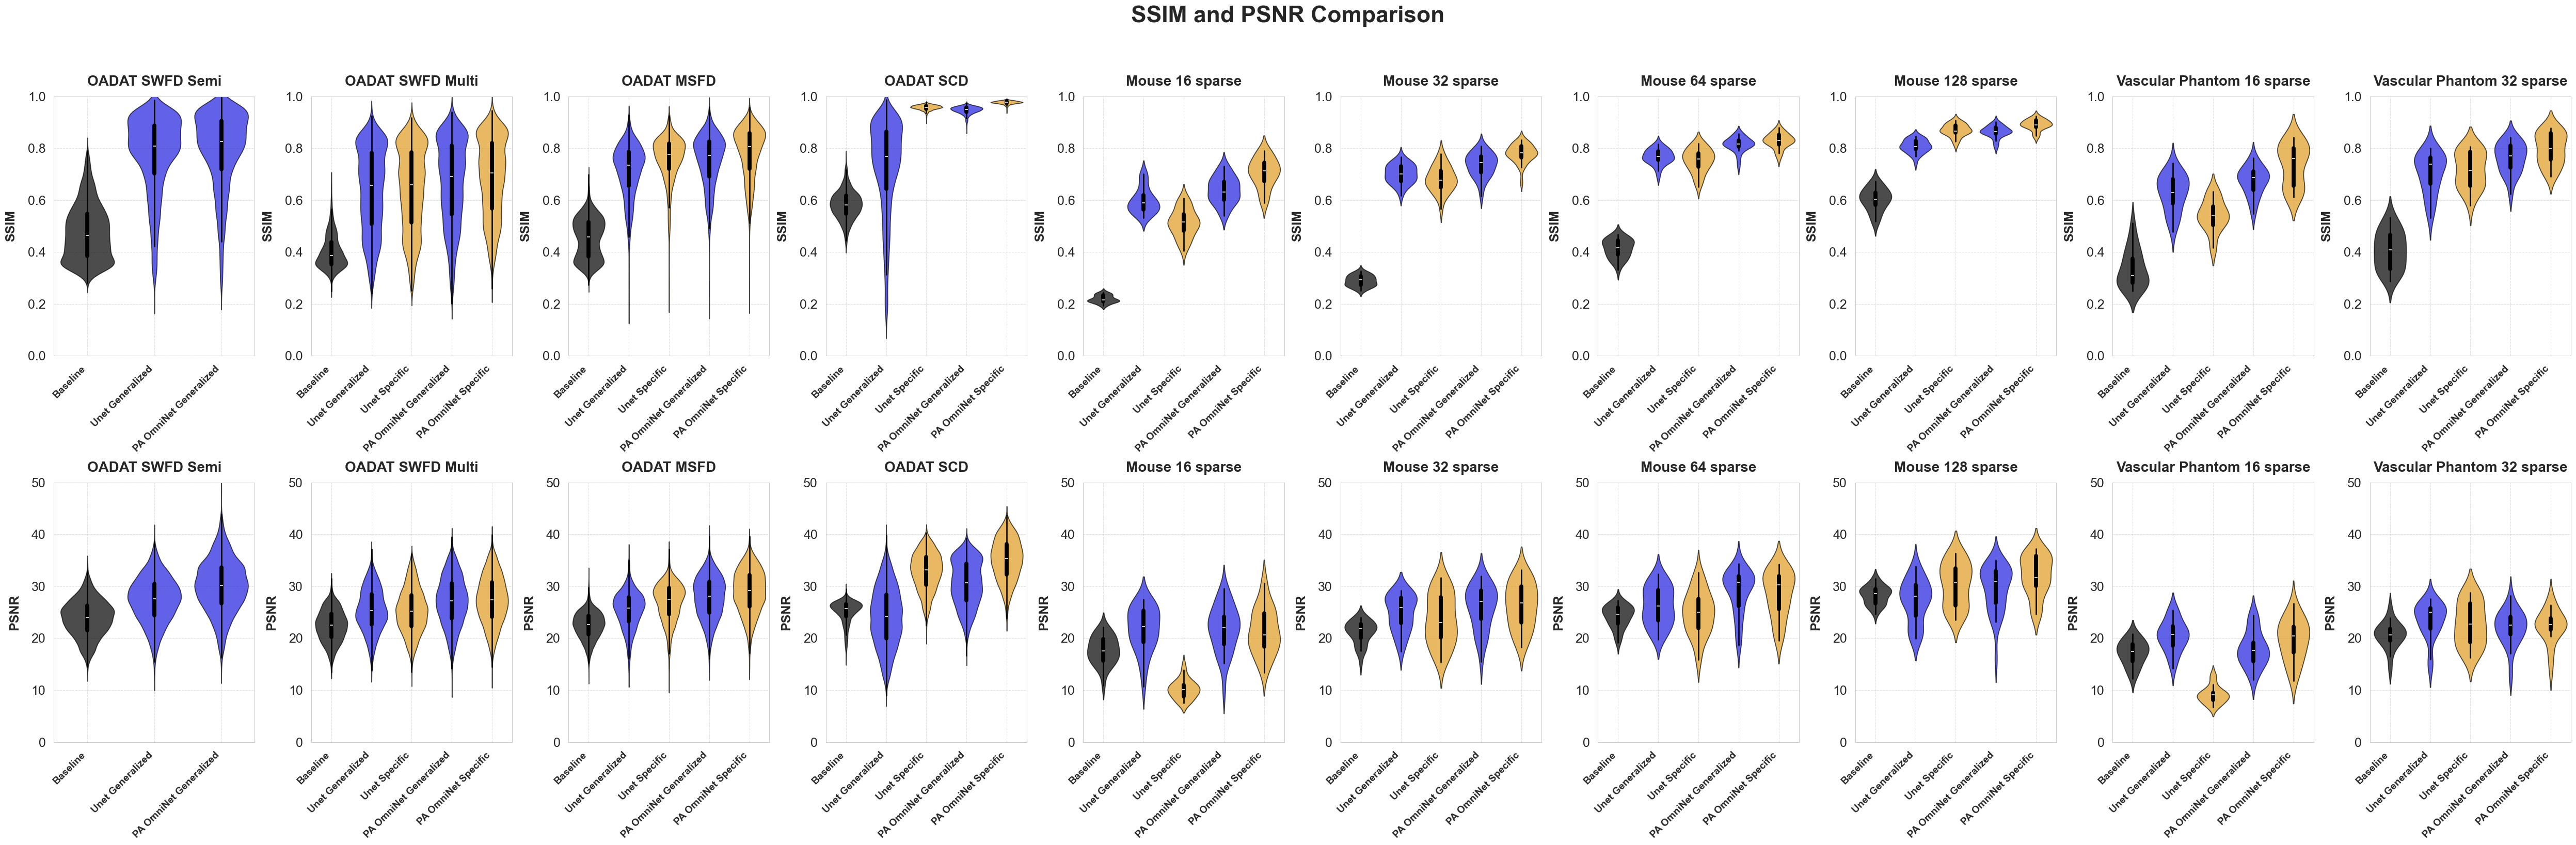

In [18]:
metrics = ['SSIM', 'PSNR']

color_mapping = {
    'Baseline': 'black',
    'Unet Generalized': 'blue',
    'Unet Specific': 'orange',
    'PA OmniNet Generalized': 'blue',
    'PA OmniNet Specific': 'orange'
}

def process_csv(file_path):
    df = pd.read_csv(file_path)
    return df

y_axis_limits = {
    'SSIM': (0, 1),
    'PSNR': (0, 50),
}

num_datasets = len(datasets)
fig, axes = plt.subplots(2, num_datasets, figsize=(5 * num_datasets, 16))
fig.suptitle('SSIM and PSNR Comparison', fontsize=32, weight='bold', y=1.02)

for row_idx, metric in enumerate(metrics):
    for col_idx, (dataset_name, dataset_dict) in enumerate(datasets.items()):
        ax = axes[row_idx, col_idx]
        ax.set_title(dataset_name, fontsize=20, weight='bold', pad=15)

        data, labels, colors = [], [], []
        for label, file_path in dataset_dict.items():
            df = process_csv(file_path)
            data.append(df[metric].values)
            labels.append(label)
            colors.append(color_mapping.get(label, 'gray'))

        sns.violinplot(data=data, ax=ax, palette=colors, alpha=0.7)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=14, weight='bold')
        ax.set_ylabel(metric, fontsize=18, weight='bold', labelpad=15)
        ax.tick_params(axis='y', which='major', labelsize=18, width=2, length=8)
        ax.tick_params(axis='x', which='major', labelsize=14, width=2, length=8)
        if metric in y_axis_limits:
            ax.set_ylim(y_axis_limits[metric])
        ax.grid(True, linestyle='--', alpha=0.6)

plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()



In [31]:
def value_difference(val1, val2, is_rmse=False, is_psnr=False):
    if is_psnr:
        return val1 - val2
    diff = ((val1 - val2) / val2) * 100
    return -diff if is_rmse else diff

def analyze_differences(datasets):
    overall_differences = {'SSIM': [], 'RMSE': [], 'PSNR': []}
    table_rows = []

    for dataset_name, dataset_dict in datasets.items():
        if 'Unet Generalized' in dataset_dict and 'PA OmniNet Generalized' in dataset_dict:
            unet_key = 'Unet Generalized'
            pa_omninet_key = 'PA OmniNet Generalized'
        elif 'Unet' in dataset_dict and 'PA OmniNet' in dataset_dict:
            unet_key = 'Unet'
            pa_omninet_key = 'PA OmniNet'
        else:
            print(f"Skipping {dataset_name}: Missing required keys")
            continue

        try:
            df_unet = pd.read_csv(dataset_dict[unet_key])
            df_pa_omninet = pd.read_csv(dataset_dict[pa_omninet_key])

            differences = {}
            for metric in ['SSIM', 'RMSE', 'PSNR']:
                unet_value = df_unet[metric].mean()
                pa_omninet_value = df_pa_omninet[metric].mean()
                is_rmse = (metric == 'RMSE')
                is_psnr = (metric == 'PSNR')
                difference = value_difference(pa_omninet_value, unet_value, is_rmse, is_psnr)
                differences[metric] = difference
                overall_differences[metric].append(difference)

            table_rows.append(f"{dataset_name} & {differences['SSIM']:.5f} & {differences['RMSE']:.2f} & {differences['PSNR']:.2f} \\\\")
        except Exception as e:
            print(f"Error processing {dataset_name}: {e}")
    avg_differences = {metric: sum(values) / len(values) for metric, values in overall_differences.items()}
    table_rows.append(f"\\textbf{{Average Improvement}} & {avg_differences['SSIM']:.2f} & {avg_differences['RMSE']:.2f} & {avg_differences['PSNR']:.2f}\\\\")
    latex_table = "\n".join(table_rows)

    print(latex_table)

datasets = {
    'OADAT SWFD Semi': Semi_paper,
    'OADAT SWFD Multi': Multi_paper,
    'OADAT MSFD': MSFD_paper,
    'OADAT SCD': SCD_paper,
    'Mouse 16 sparse': Mouse16_paper,
    'Mouse 32 sparse': Mouse32_paper,
    'Mouse 64 sparse': Mouse64_paper,
    'Mouse 128 sparse': Mouse128_paper,
    'Vascular Phantom 16 sparse': Vphantom16_paper,
    'Vascular Phantom 32 sparse': Vphantom32_paper,
}

analyze_differences(datasets)

OADAT SWFD Semi & 2.25630 & 23.23 & 2.70 \\
OADAT SWFD Multi & 4.46728 & 14.69 & 1.70 \\
OADAT MSFD & 5.28449 & 22.10 & 2.40 \\
OADAT SCD & 30.48939 & 55.99 & 6.41 \\
Mouse 16 sparse & 6.88547 & 0.40 & 0.12 \\
Mouse 32 sparse & 4.96207 & 7.43 & 1.06 \\
Mouse 64 sparse & 6.19363 & 23.92 & 2.78 \\
Mouse 128 sparse & 6.92262 & 20.40 & 2.31 \\
Vascular Phantom 16 sparse & 7.08822 & -35.50 & -2.53 \\
Vascular Phantom 32 sparse & 8.40817 & -16.86 & -1.42 \\
\textbf{Average Improvement} & 8.30 & 11.58 & 1.55\\


In [22]:
def value_difference(val1, val2, is_rmse=False, is_psnr=False):
    if is_psnr:
        return val1 - val2
    diff = ((val1 - val2) / val2) * 100
    return -diff if is_rmse else diff

def analyze_differences(datasets):
    overall_differences = {'SSIM': [], 'RMSE': [], 'PSNR': []}
    table_rows = []

    unet_metrics = {'SSIM': [], 'RMSE': [], 'PSNR': []}
    pa_omninet_metrics = {'SSIM': [], 'RMSE': [], 'PSNR': []}

    for dataset_name, dataset_dict in datasets.items():
        if 'Unet Specific' in dataset_dict and 'PA OmniNet Specific' in dataset_dict:
            unet_key = 'Unet Specific'
            pa_omninet_key = 'PA OmniNet Specific'
        elif 'Unet' in dataset_dict and 'PA OmniNet' in dataset_dict:
            unet_key = 'Unet'
            pa_omninet_key = 'PA OmniNet'
        else:
            print(f"Skipping {dataset_name}: Missing required keys")
            continue

        try:
            df_unet = pd.read_csv(dataset_dict[unet_key])
            df_pa_omninet = pd.read_csv(dataset_dict[pa_omninet_key])

            differences = {}
            for metric in ['SSIM', 'RMSE', 'PSNR']:
                unet_value = df_unet[metric].mean()
                pa_omninet_value = df_pa_omninet[metric].mean()
                unet_metrics[metric].append(unet_value)
                pa_omninet_metrics[metric].append(pa_omninet_value)
                is_rmse = (metric == 'RMSE')
                is_psnr = (metric == 'PSNR')
                difference = value_difference(pa_omninet_value, unet_value, is_rmse, is_psnr)
                differences[metric] = difference
                overall_differences[metric].append(difference)

            table_rows.append(f"{dataset_name} & {differences['SSIM']:.2f} & {differences['RMSE']:.2f} & {differences['PSNR']:.2f} \\\\")
        except Exception as e:
            print(f"Error processing {dataset_name}: {e}")
    avg_differences = {metric: sum(values) / len(values) for metric, values in overall_differences.items()}
    table_rows.append(f"\\textbf{{Average Improvement}} & {avg_differences['SSIM']:.2f} & {avg_differences['RMSE']:.2f} & {avg_differences['PSNR']:.2f} \\\\")
    latex_table = "\n".join(table_rows)
    print("\nLaTeX Table:\n")
    print(latex_table)
    print("\nPaired t-test results (PA OmniNet vs. Unet):")
    for metric in ['SSIM', 'RMSE', 'PSNR']:
        t_stat, p_value = ttest_rel(pa_omninet_metrics[metric], unet_metrics[metric])
        print(f"{metric}: t = {t_stat:.4f}, p = {p_value:.4f}")
analyze_differences(datasets)


Skipping OADAT SWFD Semi: Missing required keys

LaTeX Table:

OADAT SWFD Multi & 7.06 & 19.55 & 2.08 \\
OADAT MSFD & 3.13 & 19.16 & 2.06 \\
OADAT SCD & 1.98 & 22.06 & 2.30 \\
Mouse 16 sparse & 37.77 & 69.70 & 11.22 \\
Mouse 32 sparse & 14.36 & 27.62 & 2.62 \\
Mouse 64 sparse & 10.01 & 33.06 & 3.64 \\
Mouse 128 sparse & 2.46 & 19.45 & 1.78 \\
Vascular Phantom 16 sparse & 36.01 & 67.72 & 10.58 \\
Vascular Phantom 32 sparse & 11.28 & -2.53 & -0.46 \\
\textbf{Average Improvement} & 13.78 & 30.64 & 3.98 \\

Paired t-test results (PA OmniNet vs. Unet):
SSIM: t = 3.6443, p = 0.0065
RMSE: t = -1.8291, p = 0.1048
PSNR: t = 2.9319, p = 0.0189


In [2]:

patient_Multi_id_plot =  {   'Baseline SWFD Multi': 'test_results/OADAT/Multi/Multi_baseline.csv',
    # 'U-net Generalized': 'metrics/patients/Multi/metricsSemi_on_Multiearly.csv',
    # 'U-net Specific': 'metrics/patients/Multi/metricsMulti_on_Multiearly.csv',
    'PA OmniNet Generalized ID 1': 'test_results/OADAT/Multi_id/PAOmniNet_Generalized_alpha_Multi_id1.csv',
    'PA OmniNet Specific ID 1': 'test_results/OADAT/Multi_id/PAOmniNet_Specific_alpha_Multi_id1.csv',
    'PA OmniNet Generalized ID 2': 'test_results/OADAT/Multi_id/PAOmniNet_Generalized_alpha_Multi_id2.csv',
    'PA OmniNet Specific ID 2': 'test_results/OADAT/Multi_id/PAOmniNet_Specific_alpha_Multi_id2.csv',
    'PA OmniNet Generalized ID 3': 'test_results/OADAT/Multi_id/PAOmniNet_Generalized_alpha_Multi_id3.csv',
    'PA OmniNet Specific ID 3': 'test_results/OADAT/Multi_id/PAOmniNet_Specific_alpha_Multi_id3.csv',
    'PA OmniNet Generalized ID 4': 'test_results/OADAT/Multi_id/PAOmniNet_Generalized_alpha_Multi_id4.csv',
    'PA OmniNet Specific ID 4': 'test_results/OADAT/Multi_id/PAOmniNet_Specific_alpha_Multi_id4.csv',
    'PA OmniNet Generalized ID 5': 'test_results/OADAT/Multi_id/PAOmniNet_Generalized_alpha_Multi_id5.csv',
    'PA OmniNet Specific ID 5': 'test_results/OADAT/Multi_id/PAOmniNet_Specific_alpha_Multi_id5.csv',
}

In [9]:
table(patient_Multi_id_plot)

Statistics for Baseline SWFD Multi:
SSIM: Mean 0.4003 Std 0.0639
RMSE: Mean 0.0804 Std 0.0293
PSNR: Mean 22.4400 Std 3.0677


Statistics for PA OmniNet Generalized ID 1:
SSIM: Mean 0.6652 Std 0.1659
RMSE: Mean 0.0519 Std 0.0307
PSNR: Mean 27.0251 Std 4.7522


Statistics for PA OmniNet Specific ID 1:
SSIM: Mean 0.6833 Std 0.1538
RMSE: Mean 0.0506 Std 0.0283
PSNR: Mean 27.1555 Std 4.6537


Statistics for PA OmniNet Generalized ID 2:
SSIM: Mean 0.6672 Std 0.1634
RMSE: Mean 0.0527 Std 0.0311
PSNR: Mean 26.9058 Std 4.8030


Statistics for PA OmniNet Specific ID 2:
SSIM: Mean 0.6854 Std 0.1539
RMSE: Mean 0.0501 Std 0.0279
PSNR: Mean 27.2643 Std 4.6982


Statistics for PA OmniNet Generalized ID 3:
SSIM: Mean 0.6659 Std 0.1641
RMSE: Mean 0.0516 Std 0.0300
PSNR: Mean 27.0380 Std 4.6951


Statistics for PA OmniNet Specific ID 3:
SSIM: Mean 0.6827 Std 0.1556
RMSE: Mean 0.0489 Std 0.0261
PSNR: Mean 27.3766 Std 4.5103


Statistics for PA OmniNet Generalized ID 4:
SSIM: Mean 0.6660 Std 0.1655
RMSE: 

In [24]:
def table_full_violin(metrics_dict):
    for model, filepath in metrics_dict.items():
        df = pd.read_csv(filepath, index_col=0)
        mean_values = calculate_mean(df)
        std_values = calculate_std(df)

        print(f"Statistics for {model}:")
        for col in mean_values.index:
            print(f"{col}: Mean {mean_values[col]:.4f} Std {std_values[col]:.4f}")
        print("\n")

        df_long = df.melt(var_name='Metric', value_name='Value')

        for metric_group in ['SSIM', 'RMSE', 'PSNR']:
            metric_data = df_long[df_long['Metric'].str.contains(metric_group)]
            if not metric_data.empty:
                plt.figure(figsize=(10, 6))
                sns.violinplot(
                    data=metric_data,
                    x='Value',
                    y='Metric',
                    orient='h',
                    palette="Set2"
                )
                plt.title(f'{model} - {metric_group} Distributions')
                plt.xlabel('Value')
                plt.ylabel('Metrics')
                plt.tight_layout()
                plt.show()

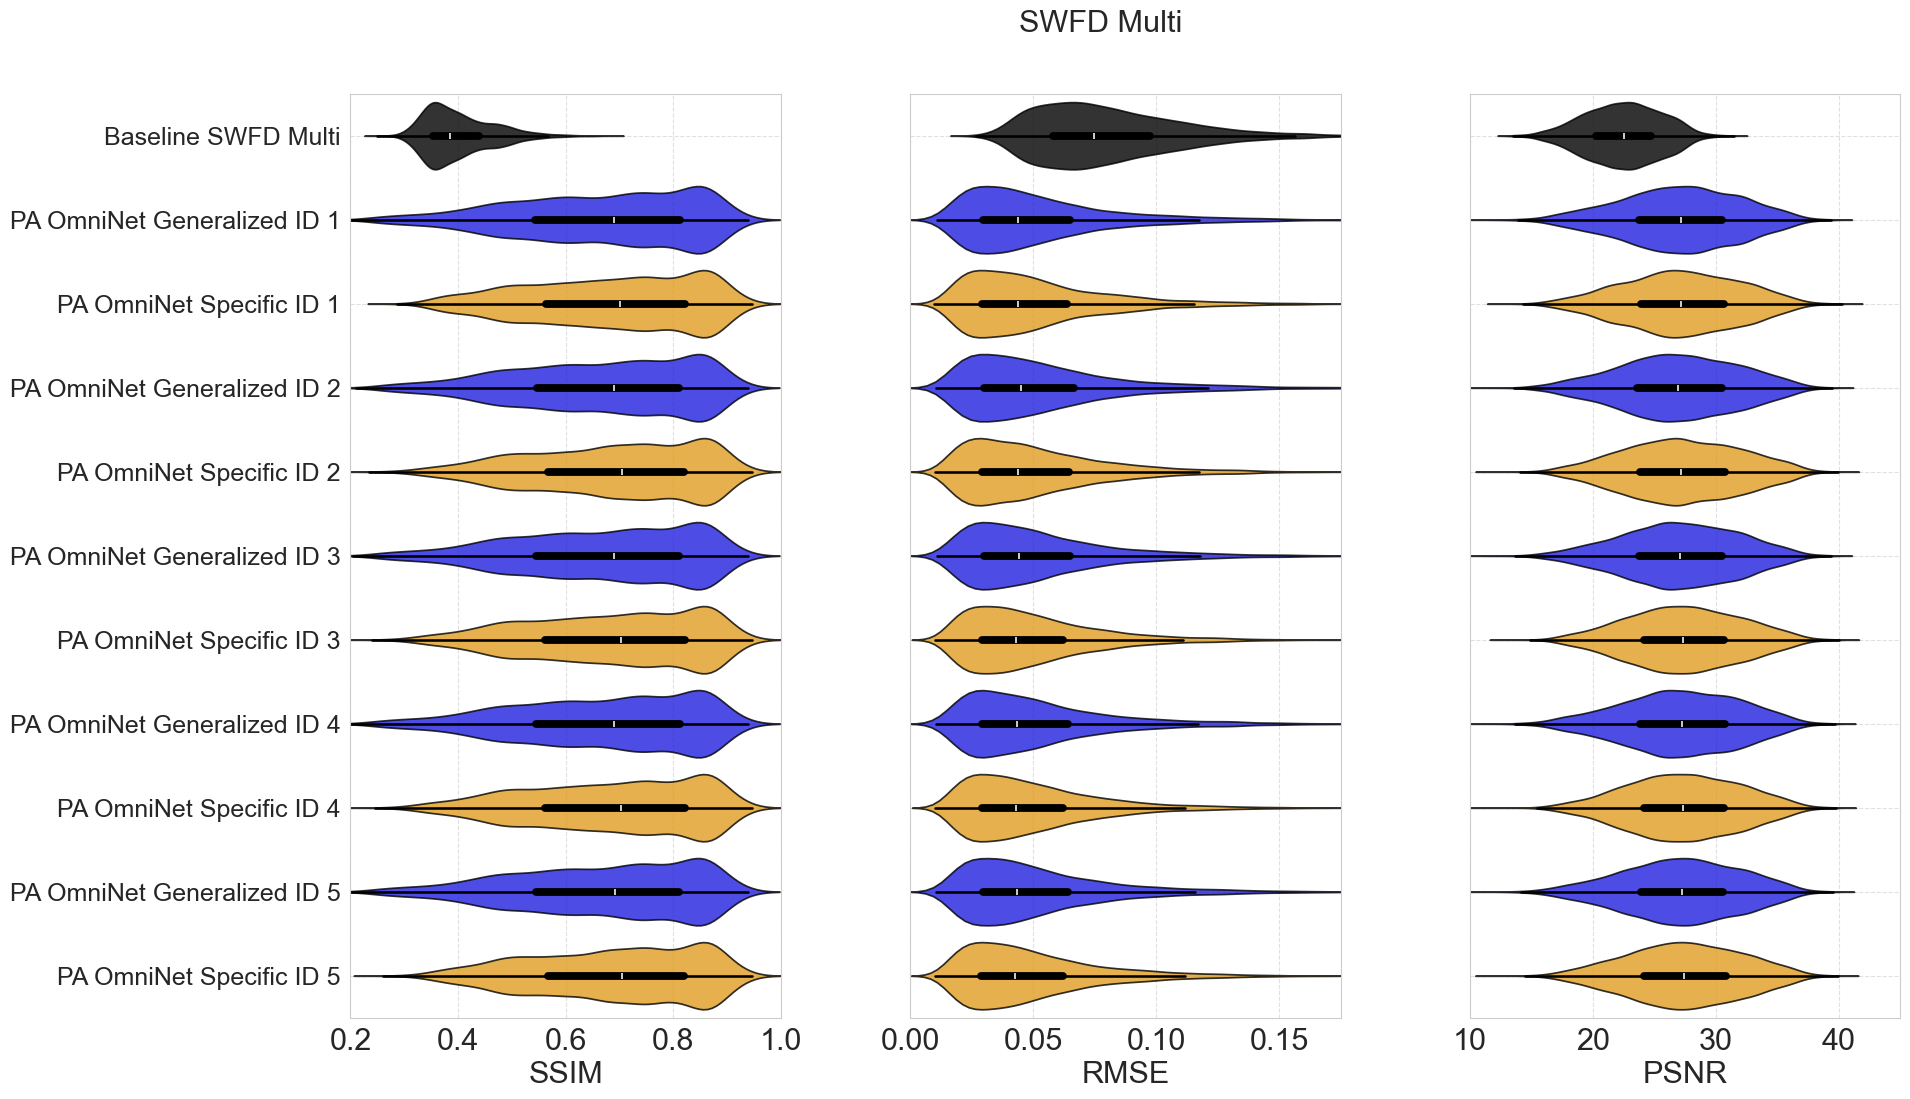

In [41]:
def load_data(file_paths):
    mean_values = []
    std_values = []
    dataframes = []
    labels = []

    for label, file_path in file_paths.items():
        if os.path.exists(file_path):
            data = pd.read_csv(file_path)
            data['Label'] = label
            dataframes.append(data)
            labels.append(label)
        else:
            print(f"File not found: {file_path}")

    combined_df = pd.concat(dataframes, ignore_index=True) if dataframes else pd.DataFrame()
    return combined_df, labels

combined_df, labels_1 = load_data(patient_Multi_id_plot)

def get_palette():
    palette = {}
    for label in labels_1:
        if 'Baseline' in label:
            palette[label] = 'black'
        elif 'Specific' in label:
            palette[label] = 'orange'
        elif 'Generalized' in label:
            palette[label] = 'blue'
        else:
            palette[label] = 'gray'
    return palette

metrics = ['SSIM', 'RMSE', 'PSNR']
palette = get_palette()

fig, ax = plt.subplots(1, len(metrics), figsize=(20, 12), sharey=True, gridspec_kw={'wspace': 0.3})

for i, metric in enumerate(metrics):
    if metric in combined_df.columns:
        sns.violinplot(
            data=combined_df,
            x=metric,
            y="Label",
            ax=ax[i],
            density_norm="width",
            orient="h",
            palette=palette, alpha=0.8,
            hue="Label",
            legend=False,
        )
        ax[i].set_xlabel(metric, fontsize=22)
        ax[i].set_ylabel('')
        ax[i].grid(True, linestyle='--', alpha=0.6)
        ax[i].tick_params(axis='x', labelsize=22)
        ax[i].tick_params(axis='y', labelsize=18)
        if metric == 'SSIM':
            ax[i].set_xlim(0.2, 1)
        elif metric == 'PSNR':
            ax[i].set_xlim(10, 45)
        elif metric == 'RMSE':
            ax[i].set_xlim(0.0, 0.175)

fig.suptitle("SWFD Multi", fontsize=22, y=0.95)
plt.show()

In [28]:
dir_path = "test_results/OADAT/context_csv_paper"
import os
import pandas as pd
ssim_averages = []
psnr_averages = []
rmse_averages = []

for context_size in range(1, 33):
    file_name = f"PA_OmniNet_Specific_MSFD_contextsize{context_size}.csv"
    file_path = os.path.join(dir_path, file_name)

    if os.path.exists(file_path):
        df = pd.read_csv(file_path)

        ssim_averages.append(df["SSIM"].mean())
        psnr_averages.append(df["PSNR"].mean())
        rmse_averages.append(df["RMSE"].mean())
    else:
        print(f"Warning: {file_name} not found.")

print("SSIM Averages:", ssim_averages)
print("PSNR Averages:", psnr_averages)
print("RMSE Averages:", rmse_averages)

SSIM Averages: [0.7806382891083402, 0.781247286756656, 0.7816875756398908, 0.782166404521891, 0.7824692583855773, 0.7824859341420233, 0.7826005970500409, 0.7827617083010929, 0.782940540742129, 0.783166222628206, 0.7832800453794854, 0.7834353102317878, 0.7835817474845265, 0.7836696480959654, 0.7838300068836127, 0.7839778129889496, 0.7841228040627071, 0.7841856097217117, 0.7842948518507182, 0.7844039982903217, 0.784449333881161, 0.7845395249075123, 0.7846287042780646, 0.7847555437577622, 0.7848590394615063, 0.7849133112574262, 0.784953694817211, 0.784995719439217, 0.785017104582595, 0.7850793271511793, 0.7851250035023051, 0.785153193540339]
PSNR Averages: [28.773164188689723, 28.87750860837975, 28.891018078009346, 28.89811139923456, 28.894557155083927, 28.848138134214594, 28.842461105093278, 28.840419158678213, 28.855503798604275, 28.865551966565597, 28.85315489624927, 28.88074120473891, 28.885047747607096, 28.882784940293224, 28.895356953181782, 28.920231254953173, 28.930763613450587, 2

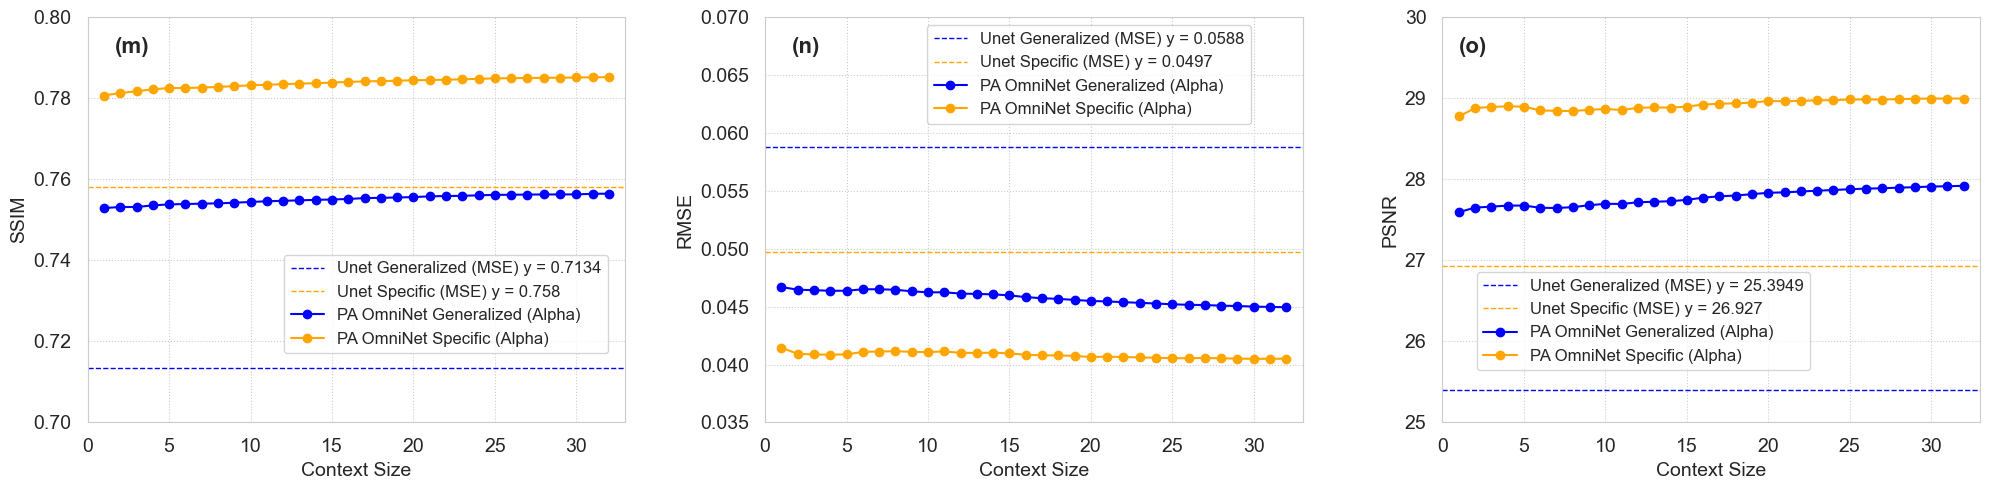

In [40]:
import numpy as np
import matplotlib.pyplot as plt

def plot_figure_ssim(ax, horizontal_lines, connected_lines, horizontal_colors, connected_colors, horizontal_labels):
    x = list(range(1, 33))

    for y, color, label in zip(horizontal_lines, horizontal_colors, horizontal_labels):
        ax.axhline(y=y, color=color, linestyle='--', linewidth=1, label=f'{label} y = {y}')

    for y_values, color, label in zip(connected_lines, connected_colors, ['PA OmniNet Generalized (Alpha)', 'PA OmniNet Specific (Alpha)']):
        ax.plot(x, y_values, color=color, marker='o', label=label)
    ax.set_ylim(.7, .8)
    ax.set_xlabel('Context Size', fontsize=14)
    ax.set_ylabel('SSIM', fontsize=14)
    ax.legend(fontsize=12, loc='best', bbox_to_anchor=(0.35, 0.15
                                                       , 0.5, 0.5))
    ax.grid(True, linestyle=':')
    ax.tick_params(axis='y', which='major', labelsize=14, width=2, length=8)
    ax.tick_params(axis='x', which='major', labelsize=14, width=2, length=8)
    # ax.show()

def plot_figure_rmse(ax, horizontal_lines, connected_lines, horizontal_colors, connected_colors, horizontal_labels):
    x = list(range(1, 33))

    for y, color, label in zip(horizontal_lines, horizontal_colors, horizontal_labels):
        ax.axhline(y=y, color=color, linestyle='--', linewidth=1, label=f'{label} y = {y}')

    for y_values, color, label in zip(connected_lines, connected_colors, ['PA OmniNet Generalized (Alpha)', 'PA OmniNet Specific (Alpha)']):
        ax.plot(x, y_values, color=color, marker='o', label=label)

    ax.set_xlabel('Context Size', fontsize=14)
    ax.set_ylabel('RMSE', fontsize=14)
    ax.set_ylim(0.035, .07)
    ax.legend(fontsize=12, loc='best', bbox_to_anchor=(0.42, 0.5, 0.5, 0.5))
    ax.grid(True, linestyle=':')
    ax.tick_params(axis='y', which='major', labelsize=14, width=2, length=8)
    ax.tick_params(axis='x', which='major', labelsize=14, width=2, length=8)
    # ax.set_title("RMSE")

def plot_figure_psnr(ax, horizontal_lines, connected_lines, horizontal_colors, connected_colors, horizontal_labels):
    x = list(range(1, 33))

    for y, color, label in zip(horizontal_lines, horizontal_colors, horizontal_labels):
        ax.axhline(y=y, color=color, linestyle='--', linewidth=1, label=f'{label} y = {y}')

    for y_values, color, label in zip(connected_lines, connected_colors, ['PA OmniNet Generalized (Alpha)', 'PA OmniNet Specific (Alpha)'
                                                                                                            '']):
        ax.plot(x, y_values, color=color, marker='o', label=label)
    ax.set_ylim(25, 30)
    ax.set_xlabel('Context Size', fontsize=14)
    ax.set_ylabel('PSNR', fontsize=14)
    ax.legend(fontsize=12, loc='best', bbox_to_anchor=(0.2, 0.0, 0.5, 0.5))
    ax.grid(True, linestyle=':')
    ax.tick_params(axis='y', which='major', labelsize=14, width=2, length=8)
    ax.tick_params(axis='x', which='major', labelsize=14, width=2, length=8)
    # ax.set_title("PSNR")
horizontal_liness = [ 0.7134, 0.7580]
# 0.4524
connected_liness = ([0.7528838780123208, 0.7531369487462299, 0.753148429675826, 0.7535260380006262, 0.7537928818379129, 0.7538663445280066, 0.753969422190317, 0.754040538924081, 0.7541947611421347, 0.7543848245883626, 0.7545507068905447, 0.7546722141467035, 0.7547758838773838, 0.7549092272136892, 0.7549884652186717, 0.7551138453425041, 0.7553438350079315, 0.7554017705629978, 0.7554948093848569, 0.7555815720637994, 0.7557735982750143, 0.7558470013870725, 0.7559008871551071, 0.7560149183683097, 0.7561380940037115, 0.7561546473710664, 0.7562117498288197, 0.7562315181536334, 0.7562399520006563, 0.7562482079437801, 0.7563964325455682, 0.7564290412728275], [0.7806382891083402, 0.781247286756656, 0.7816875756398908, 0.782166404521891, 0.7824692583855773, 0.7824859341420233, 0.7826005970500409, 0.7827617083010929, 0.782940540742129, 0.783166222628206, 0.7832800453794854, 0.7834353102317878, 0.7835817474845265, 0.7836696480959654, 0.7838300068836127, 0.7839778129889496, 0.7841228040627071, 0.7841856097217117, 0.7842948518507182, 0.7844039982903217, 0.784449333881161, 0.7845395249075123, 0.7846287042780646, 0.7847555437577622, 0.7848590394615063, 0.7849133112574262, 0.784953694817211, 0.784995719439217, 0.785017104582595, 0.7850793271511793, 0.7851250035023051, 0.785153193540339] )
horizontal_linesr = [0.0588 , 0.0497]
# connected_lines = ([0.0533,0.0856,0.0850, 0.0896], [ 0.0999,0.1026,0.1057, 0.1111])
connected_linesr = ([0.046692895247960185, 0.0464603316818337, 0.046419188109796804, 0.04636822488299637, 0.04637125557083073, 0.04649537827837459, 0.04649989706464591, 0.04645609104140553, 0.04632277406273015, 0.04623548595073795, 0.046236810663265626, 0.04612694425112442, 0.046096465887256834, 0.046058267036864664, 0.04596967098821194, 0.04582367545823707, 0.04572468615604434, 0.045668440573523796, 0.04558055203054454, 0.04548897021644474, 0.04544844275706394, 0.04538379615779478, 0.045328652564197276, 0.04526677656611872, 0.04520089971974048, 0.04515636822069819, 0.045134037813197296, 0.04508435828730831, 0.045051138258066614, 0.04500540631271319, 0.0449734460568929, 0.044948435731126495], [0.041449110006526596, 0.04092890896172406, 0.04086899829233496, 0.04085119217877092, 0.04087379241437705, 0.04109551867417773, 0.04112268775122088, 0.041150198302181897, 0.0410974191013326, 0.041070406863298374, 0.04113674062345596, 0.04101180974516835, 0.041004070376563014, 0.041023541062088754, 0.0409662934966059, 0.04084249599545161, 0.04080112195120432, 0.0407829192341354, 0.040749544542673224, 0.040648206790401695, 0.040680175332677156, 0.04064741157668124, 0.04061353963915579, 0.040591046717581916, 0.040546560330009425, 0.04054425587611149, 0.04057064020532718, 0.0405348471241742, 0.04051490710915325, 0.04049291392331194, 0.04049803610972484, 0.04050734558437983])
# Sample data (Replace with your actual data)
horizontal_linesp = [25.3949, 26.9270]
# connected_lines = ([26.2259, 22.0708,22.2310,21.8306], [21.1952,20.9562,20.6798, 20.2964])
connected_linesp = ( [27.593153064334963, 27.64967057614345, 27.66150767357941, 27.6742083563397, 27.675067166521814, 27.647573047065578, 27.644524746263922, 27.65541031156705, 27.67855057916763, 27.696502528287304, 27.694387765464356, 27.715438819169062, 27.721844982920217, 27.728341536762656, 27.74511441209081, 27.77215675261556, 27.7886795859945, 27.798831016052166, 27.815075951878086, 27.832426420307332, 27.837552491962388, 27.848202099310637, 27.85794789446046, 27.86632762543773, 27.87643869967944, 27.883908031182624, 27.887884184829144, 27.89584112643683, 27.901240192943142, 27.909392360308296, 27.91298312232606, 27.918404873355435],  [28.773164188689723, 28.87750860837975, 28.891018078009346, 28.89811139923456, 28.894557155083927, 28.848138134214594, 28.842461105093278, 28.840419158678213, 28.855503798604275, 28.865551966565597, 28.85315489624927, 28.88074120473891, 28.885047747607096, 28.882784940293224, 28.895356953181782, 28.920231254953173, 28.930763613450587, 28.935818187945397, 28.943904229462937, 28.964304579770744, 28.960489142783242, 28.966107359512186, 28.972138718109466, 28.975029444798025, 28.983023653593253, 28.984263569158927, 28.98179523076911, 28.988034643169104, 28.99169569484681, 28.994432617993443, 28.994226570504356, 28.99477277149754]
)
horizontal_labels = [ 'Unet Generalized (MSE)', 'Unet Specific (MSE)']
horizontal_colors = [ 'blue', 'orange']
connected_colors = ['blue', 'orange']
# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=False)


for ax in axes:  # If you have multiple subplots
    ax.set_xlim(0, 33)  # Set the correct context size range
    ax.set_xticks(np.arange(0, 33, step=5))  # Ensure evenly spaced tick marks
    ax.set_xticklabels(np.arange(0, 33, step=5), fontsize=12)  # Proper formatting

plot_figure_ssim(axes[0], horizontal_liness, connected_liness, horizontal_colors, connected_colors, horizontal_labels)
axes[0].text(0.05, 0.95, '(m)', transform=axes[0].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

plot_figure_rmse(axes[1], horizontal_linesr, connected_linesr, horizontal_colors, connected_colors, horizontal_labels)
axes[1].text(0.05, 0.95, '(n)', transform=axes[1].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

plot_figure_psnr(axes[2], horizontal_linesp, connected_linesp, horizontal_colors, connected_colors, horizontal_labels)
axes[2].text(0.03, 0.95, '(o)', transform=axes[2].transAxes, fontsize=16, fontweight='bold', va='top', ha='left')

plt.xlabel('Context Size')
plt.tight_layout()
plt.show()


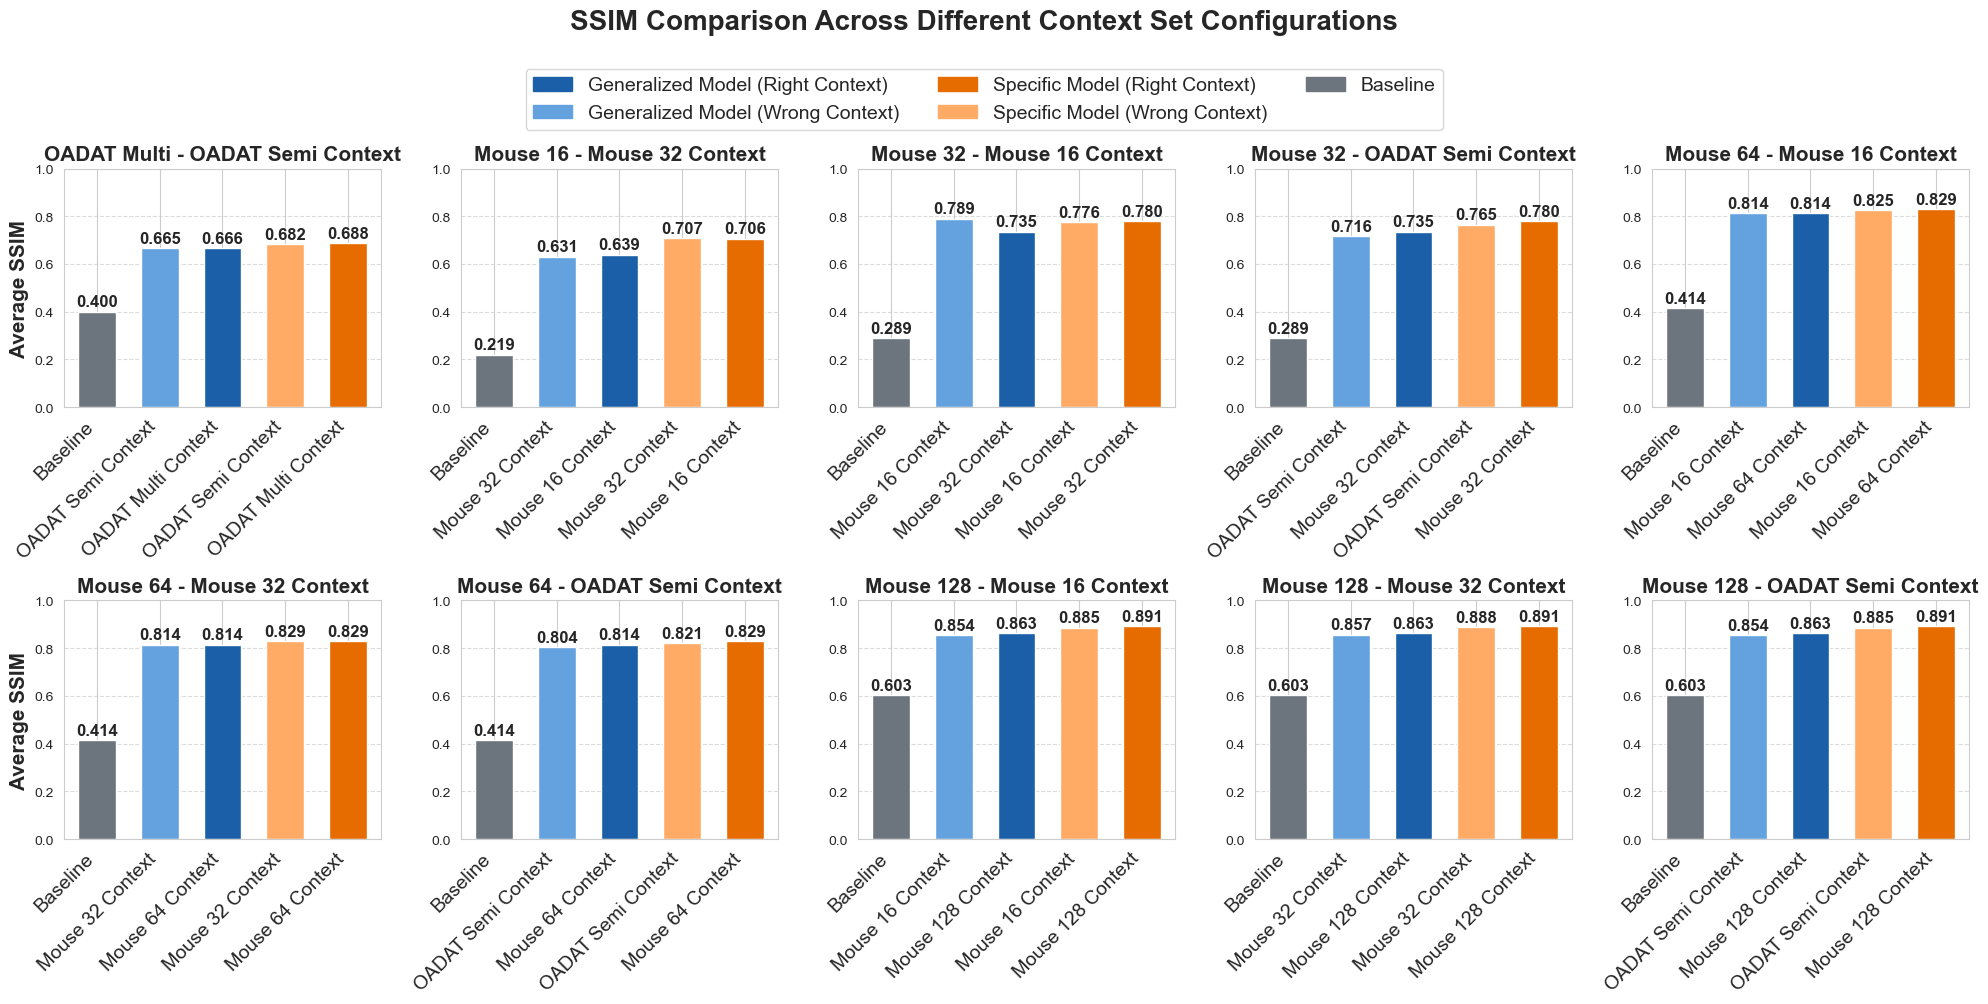

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_horizontal_ssim_comparisons(all_dicts, dict_names=None, custom_display_names=None, rows=1, cols=None):

    if dict_names is None:
        dict_names = [f"Dataset {i+1}" for i in range(len(all_dicts))]

    n_dicts = len(all_dicts)
    if cols is None:
        cols = int(np.ceil(n_dicts / rows))

    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 5 * rows))

    axes = np.array(axes).reshape(rows, cols)

    standard_model_names = {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'Generalized Model (Wrong Context)',
        'Pre-trained Conditional Generator (with context)': 'Generalized Model (Right Context)',
        'Pre-trained Chamfer Generator (no context)': 'Specific Model (Wrong Context)',
        'Pre-trained Chamfer Generator (with context)': 'Specific Model (Right Context)'
    }

    color_dict = {
        'Generalized Model (Right Context)': '#1a5fa7',
        'Generalized Model (Wrong Context)': '#63a2df',
        'Specific Model (Right Context)': '#e66c00',
        'Specific Model (Wrong Context)': '#ffab66',
        'Baseline': '#6c757d'
    }

    legend_handles = [
        plt.Rectangle((0,0), 1, 1, color=color_dict['Generalized Model (Right Context)']),
        plt.Rectangle((0,0), 1, 1, color=color_dict['Generalized Model (Wrong Context)']),
        plt.Rectangle((0,0), 1, 1, color=color_dict['Specific Model (Right Context)']),
        plt.Rectangle((0,0), 1, 1, color=color_dict['Specific Model (Wrong Context)']),
        plt.Rectangle((0,0), 1, 1, color=color_dict['Baseline'])
    ]
    legend_labels = list(color_dict.keys())

    default_display_names = {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'Pre-trained\nCond. Gen.\n(no context)',
        'Pre-trained Conditional Generator (with context)': 'Pre-trained\nCond. Gen.\n(with context)',
        'Pre-trained Chamfer Generator (no context)': 'Pre-trained\nChamfer Gen.\n(no context)',
        'Pre-trained Chamfer Generator (with context)': 'Pre-trained\nChamfer Gen.\n(with context)'
    }

    dict_counter = 0

    for i in range(rows):
        for j in range(cols):
            if dict_counter >= len(all_dicts):
                axes[i, j].set_visible(False)
                continue

            ax = axes[i, j]
            metrics_dict = all_dicts[dict_counter]

            models = []
            model_types = []
            ssim_values = []

            for model, filepath in metrics_dict.items():
                models.append(model)
                model_types.append(standard_model_names.get(model, 'Unknown'))

                if isinstance(filepath, str) and filepath.endswith('.csv'):
                    try:
                        df = pd.read_csv(filepath)
                        if 'SSIM' in df.columns:
                            ssim_values.append(df['SSIM'].mean())
                        else:
                            ssim_values.append(0)
                    except:
                        ssim_values.append(0)
                else:
                    ssim_values.append(filepath if isinstance(filepath, (int, float)) else 0.85)

            bar_colors = [color_dict.get(model_type, '#6c757d') for model_type in model_types]

            x_pos = np.arange(len(models))
            bar_width = 0.6
            bars = ax.bar(x_pos, ssim_values, width=bar_width, align='center',
                         alpha=1.0, color=bar_colors)


            for k, (bar, value) in enumerate(zip(bars, ssim_values)):
                if value > 0:
                    height = bar.get_height()
                    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                            f'{value:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')


            if j == 0:
                ax.set_ylabel('Average SSIM', fontsize=15, fontweight='bold')

            if dict_counter < len(dict_names):
                ax.set_title(dict_names[dict_counter], fontsize=15, fontweight='bold')

            if custom_display_names and dict_counter < len(custom_display_names):
                subplot_display_names = custom_display_names[dict_counter]
                x_labels = [subplot_display_names.get(model, default_display_names.get(model, model))
                           for model in models]
            else:
                x_labels = [default_display_names.get(model, model) for model in models]

            ax.set_xticks(x_pos)
            ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=14)

            ax.set_ylim(0, 1.0)

            ax.grid(axis='y', linestyle='--', alpha=0.7)

            ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

            dict_counter += 1

    fig.legend(legend_handles, legend_labels,
               loc='upper center',
               bbox_to_anchor=(0.5, 0.95),
               ncol=3,
               fontsize=14)

    # Add overall title
    plt.suptitle("SSIM Comparison Across Different Context Set Configurations",
                 fontsize=20, fontweight='bold', y=1.0)

    plt.tight_layout(rect=[0, 0.0, 1, 0.92])

    return fig

different_context_Multi = {
    'Baseline': 0.400,
    'Pre-trained Conditional Generator (no context)': 0.665,
    'Pre-trained Conditional Generator (with context)': 0.666,
    'Pre-trained Chamfer Generator (no context)': 0.682,
    'Pre-trained Chamfer Generator (with context)': 0.688
}

different_context_Mouse16_context32 = {
    'Baseline': 0.219,
    'Pre-trained Conditional Generator (no context)': 0.631,
    'Pre-trained Conditional Generator (with context)': 0.639,
    'Pre-trained Chamfer Generator (no context)': 0.707,
    'Pre-trained Chamfer Generator (with context)': 0.706
}

different_context_Mouse32_context16 = {
    'Baseline': 0.289,
    'Pre-trained Conditional Generator (no context)': 0.789,
    'Pre-trained Conditional Generator (with context)': 0.735,
    'Pre-trained Chamfer Generator (no context)': 0.776,
    'Pre-trained Chamfer Generator (with context)': 0.780
}

different_context_Mouse32_OADATSemi = {
    'Baseline': 0.289,
    'Pre-trained Conditional Generator (no context)': 0.716,
    'Pre-trained Conditional Generator (with context)': 0.735,
    'Pre-trained Chamfer Generator (no context)': 0.765,
    'Pre-trained Chamfer Generator (with context)': 0.780
}

different_context_Mouse64_context16 = {
    'Baseline': 0.414,
    'Pre-trained Conditional Generator (no context)': 0.814,
    'Pre-trained Conditional Generator (with context)': 0.814,
    'Pre-trained Chamfer Generator (no context)': 0.825,
    'Pre-trained Chamfer Generator (with context)': 0.829
}

different_context_Mouse64_context32 = {
    'Baseline': 0.414,
    'Pre-trained Conditional Generator (no context)': 0.814,
    'Pre-trained Conditional Generator (with context)': 0.814,
    'Pre-trained Chamfer Generator (no context)': 0.829,
    'Pre-trained Chamfer Generator (with context)': 0.829
}

different_context_Mouse64_OADATSemi = {
    'Baseline': 0.414,
    'Pre-trained Conditional Generator (no context)': 0.804,
    'Pre-trained Conditional Generator (with context)': 0.814,
    'Pre-trained Chamfer Generator (no context)': 0.821,
    'Pre-trained Chamfer Generator (with context)': 0.829
}

different_context_Mouse128_context16 = {
    'Baseline': 0.603,
    'Pre-trained Conditional Generator (no context)': 0.854,
    'Pre-trained Conditional Generator (with context)': 0.863,
    'Pre-trained Chamfer Generator (no context)': 0.885,
    'Pre-trained Chamfer Generator (with context)': 0.891
}

different_context_Mouse128_context32 = {
    'Baseline': 0.603,
    'Pre-trained Conditional Generator (no context)': 0.857,
    'Pre-trained Conditional Generator (with context)': 0.863,
    'Pre-trained Chamfer Generator (no context)': 0.888,
    'Pre-trained Chamfer Generator (with context)': 0.891
}

different_context_Mouse128_OADATSemi = {
    'Baseline': 0.603,
    'Pre-trained Conditional Generator (no context)': 0.854,
    'Pre-trained Conditional Generator (with context)': 0.863,
    'Pre-trained Chamfer Generator (no context)': 0.885,
    'Pre-trained Chamfer Generator (with context)': 0.891
}

dict_names = [
    "OADAT Multi - OADAT Semi Context",
    "Mouse 16 - Mouse 32 Context",
    "Mouse 32 - Mouse 16 Context",
    "Mouse 32 - OADAT Semi Context",
    "Mouse 64 - Mouse 16 Context",
    "Mouse 64 - Mouse 32 Context",
    "Mouse 64 - OADAT Semi Context",
    "Mouse 128 - Mouse 16 Context",
    "Mouse 128 - Mouse 32 Context",
    "Mouse 128 - OADAT Semi Context"
]

all_dicts = [
    different_context_Multi,
    different_context_Mouse16_context32,
    different_context_Mouse32_context16,
    different_context_Mouse32_OADATSemi,
    different_context_Mouse64_context16,
    different_context_Mouse64_context32,
    different_context_Mouse64_OADATSemi,
    different_context_Mouse128_context16,
    different_context_Mouse128_context32,
    different_context_Mouse128_OADATSemi
]

custom_display_names = [

    {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'OADAT Semi Context',
        'Pre-trained Conditional Generator (with context)': 'OADAT Multi Context',
        'Pre-trained Chamfer Generator (no context)': 'OADAT Semi Context',
        'Pre-trained Chamfer Generator (with context)': 'OADAT Multi Context',
    },

    {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'Mouse 32 Context',
        'Pre-trained Conditional Generator (with context)': 'Mouse 16 Context',
        'Pre-trained Chamfer Generator (no context)': 'Mouse 32 Context',
        'Pre-trained Chamfer Generator (with context)': 'Mouse 16 Context'
    },

    {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'Mouse 16 Context',
        'Pre-trained Conditional Generator (with context)': 'Mouse 32 Context',
        'Pre-trained Chamfer Generator (no context)': 'Mouse 16 Context',
        'Pre-trained Chamfer Generator (with context)': 'Mouse 32 Context'
    },

    {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'OADAT Semi Context',
        'Pre-trained Conditional Generator (with context)': 'Mouse 32 Context',
        'Pre-trained Chamfer Generator (no context)': 'OADAT Semi Context',
        'Pre-trained Chamfer Generator (with context)': 'Mouse 32 Context'
    },

    {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'Mouse 16 Context',
        'Pre-trained Conditional Generator (with context)': 'Mouse 64 Context',
        'Pre-trained Chamfer Generator (no context)': 'Mouse 16 Context',
        'Pre-trained Chamfer Generator (with context)': 'Mouse 64 Context'
    },

    {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'Mouse 32 Context',
        'Pre-trained Conditional Generator (with context)': 'Mouse 64 Context',
        'Pre-trained Chamfer Generator (no context)': 'Mouse 32 Context',
        'Pre-trained Chamfer Generator (with context)': 'Mouse 64 Context'
    },

    {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'OADAT Semi Context',
        'Pre-trained Conditional Generator (with context)': 'Mouse 64 Context',
        'Pre-trained Chamfer Generator (no context)': 'OADAT Semi Context',
        'Pre-trained Chamfer Generator (with context)': 'Mouse 64 Context'
    },

    {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'Mouse 16 Context',
        'Pre-trained Conditional Generator (with context)': 'Mouse 128 Context',
        'Pre-trained Chamfer Generator (no context)': 'Mouse 16 Context',
        'Pre-trained Chamfer Generator (with context)': 'Mouse 128 Context'
    },

    {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'Mouse 32 Context',
        'Pre-trained Conditional Generator (with context)': 'Mouse 128 Context',
        'Pre-trained Chamfer Generator (no context)': 'Mouse 32 Context',
        'Pre-trained Chamfer Generator (with context)': 'Mouse 128 Context'
    },

    {
        'Baseline': 'Baseline',
        'Pre-trained Conditional Generator (no context)': 'OADAT Semi Context',
        'Pre-trained Conditional Generator (with context)': 'Mouse 128 Context',
        'Pre-trained Chamfer Generator (no context)': 'OADAT Semi Context',
        'Pre-trained Chamfer Generator (with context)': 'Mouse 128 Context'
    }
]

fig = plot_horizontal_ssim_comparisons(all_dicts, dict_names, custom_display_names, rows=2, cols=5)
plt.savefig('different_context_test_2x5.png', dpi=100, bbox_inches='tight')
plt.show()